## Task A2: Rationale for Mutation Selection

In this analysis, we compare the **Wild Type (WT)** control with two specific mutations to investigate how different mechanisms of pathway hyperactivation influence spatiotemporal ERK signaling.

### Selected Mutations:
* **WT (Wild Type):** Serves as a **baseline control** to understand normal, physiological signaling dynamics and the standard relay timescale between neighboring cells.
* **AKT1_E17K:** A **"gain-of-function"** mutation located directly in the AKT1 kinase. It promotes constitutive localization to the plasma membrane, leading to continuous activation of the pathway.
* **PTEN_del:** A **"loss-of-function"** mutation involving the deletion of a key tumor suppressor. PTEN normally acts as a "brake" on the PI3K/AKT pathway by dephosphorylating PIP3; its absence leads to uncontrolled signaling.

### Objective:
The primary goal is to determine if constitutive activation at **different stages of the signaling hierarchy** (direct kinase activation vs. loss of upstream inhibition) similarly affects how cells communicate and relay signals to their neighbors. We hypothesize that these mutations may desensitize cells to paracrine signals, potentially altering the optimal lag ($\tau^*$) or reducing the Relative Risk ($RR$) compared to the WT.

In [73]:
import sys
import subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path(r'C:\Users\user\Desktop\studia\Biologiasystemow2')
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = SCRIPTS_DIR / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = SCRIPTS_DIR / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'outputs'

EXP_ID = 1
SIGNAL_COL = 'ERKKTR_ratio'
MAX_LAG = 6

MUTATIONS_SITES = {
    "WT": 1,
    "AKT1_E17K": 5, 
    "PTEN_del": 17
}

In [74]:
processes = []
for site_id in MUTATIONS_SITES.values():
    print(f"Running analysis for site {site_id}...")
    cmd = [
        sys.executable,
        str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path', str(DATA_PATH),
        '--meta-path', str(META_PATH),
        '--exp-id', str(EXP_ID),
        '--site-id', str(site_id),
        '--signal-col', SIGNAL_COL,
        '--output-dir', str(OUTPUT_ROOT),
    ]
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    processes.append((site_id, p))

for site_id, p in processes:
    stdout, stderr = p.communicate()
    if p.returncode == 0:
        print(f"Site {site_id} processed successfully.")
    else:
        print(f"Error in site {site_id}: {stderr}")

Running analysis for site 1...
Running analysis for site 5...
Running analysis for site 17...
Site 1 processed successfully.
Site 5 processed successfully.
Site 17 processed successfully.


In [76]:
def run_lagged_analysis(mut_name, site_id):
    file_path = OUTPUT_ROOT / f"exp_{EXP_ID}_site_{site_id}_{SIGNAL_COL}" / "nodes.csv.gz"
    
    if not file_path.exists():
        print(f"Warning: File for {mut_name} not found at path {file_path}")
        return pd.DataFrame()

    df = pd.read_csv(file_path).sort_values(['track_id', 'Image_Metadata_T'])
    
    pd.set_option('future.no_silent_downcasting', True)
    
    results = []
    for t in range(MAX_LAG + 1):
        if t == 0:
            exposed_mask = df['neighbor_jump_now']
        else:
            exposed_mask = df.groupby('track_id')['neighbor_jump_now'].shift(t).fillna(False)
        
        n_exp = exposed_mask.sum()
        p_exp = df.loc[exposed_mask == True, 'future_self_jump'].mean()
        p_unexp = df.loc[exposed_mask == False, 'future_self_jump'].mean()
        
        results.append({
            'mutation': mut_name,
            'site': site_id,
            'tau (frames)': t,
            'tau (min)': t * 5,
            'n_exposed': int(n_exp),
            'p_exp': round(p_exp, 4),
            'p_unexp': round(p_unexp, 4),
            'RD': round(p_exp - p_unexp, 4),
            'RR': round(p_exp / p_unexp, 4) if p_unexp > 0 else np.nan
        })
        
    return pd.DataFrame(results)

In [77]:
final_results = pd.concat([run_lagged_analysis(m, s) for m, s in MUTATIONS_SITES.items()], ignore_index=True)

summary_df = final_results.loc[final_results.groupby('mutation')['RR'].idxmax()].copy()
summary_df = summary_df[['mutation', 'tau (frames)', 'RR']].rename(
    columns={'tau (frames)': 'optimal_lag_tau_star', 'RR': 'max_RR'}
)

print("\nFull Results Table for All Lags:")
display(final_results)

print("\nSummary of Optimal Lags")
display(summary_df)


Full Results Table for All Lags:


,mutation,site,tau (frames),tau (min),n_exposed,p_exp,p_unexp,RD,RR
0,WT,1,0,0,146620,0.1315,0.0749,0.0566,1.7558
1,WT,1,1,5,145714,0.1284,0.0772,0.0513,1.6640
2,WT,1,2,10,144813,0.1248,0.0799,0.0450,1.5627
3,WT,1,3,15,143980,0.1206,0.0829,0.0377,1.4549
4,WT,1,4,20,143194,0.1169,0.0856,0.0313,1.3661
5,WT,1,5,25,142405,0.1136,0.0878,0.0258,1.2940
6,WT,1,6,30,141705,0.1108,0.0898,0.0210,1.2337
7,AKT1_E17K,5,0,0,224573,0.1553,0.0964,0.0589,1.6109
8,AKT1_E17K,5,1,5,223505,0.1538,0.0981,0.0558,1.5684
9,AKT1_E17K,5,2,10,222404,0.1529,0.0993,0.0537,1.5405



Summary of Optimal Lags


,mutation,optimal_lag_tau_star,max_RR
7,AKT1_E17K,0,1.6109
14,PTEN_del,0,1.5731
0,WT,0,1.7558


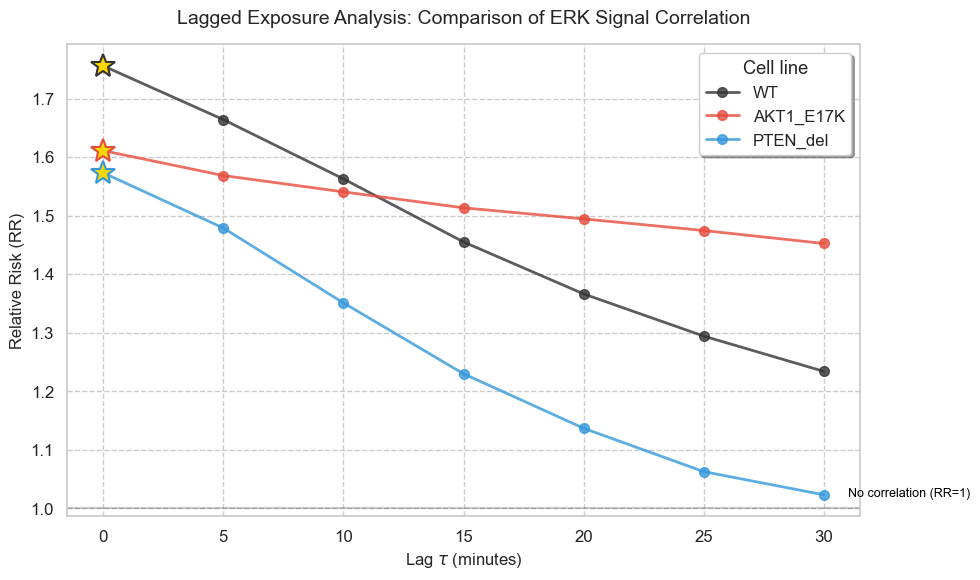

In [78]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid", {'grid.linestyle': '--'})

palette = {"WT": "#333333", "AKT1_E17K": "#e74c3c", "PTEN_del": "#3498db"}

for mutation in MUTATIONS_SITES:
    data_sub = final_results[final_results['mutation'] == mutation]
    
    plt.plot(data_sub['tau (min)'], data_sub['RR'], 
             label=mutation, 
             color=palette.get(mutation, "#999999"), 
             marker='o', markersize=7, linewidth=2, alpha=0.8)
    
    # Add highlighting for the optimal point (tau*)
    opt_row = final_results[(final_results['mutation'] == mutation) & 
                            (final_results['RR'] == summary_df.loc[summary_df['mutation'] == mutation, 'max_RR'].values[0])].iloc[0]
    
    plt.plot(opt_row['tau (min)'], opt_row['RR'], 
             marker='*', markersize=18, color='gold', 
             markeredgecolor=palette.get(mutation), markeredgewidth=1.5,
             linestyle='None', zorder=5)

# Add a reference line at RR=1 (no neighbor effect)
plt.axhline(1, color='black', linestyle='-', alpha=0.2)
plt.text(31, 1.02, 'No correlation (RR=1)', color='black', fontsize=9)

plt.title('Lagged Exposure Analysis: Comparison of ERK Signal Correlation', fontsize=14, pad=15)
plt.xlabel('Lag $\\tau$ (minutes)', fontsize=12)
plt.ylabel('Relative Risk (RR)', fontsize=12)
plt.xticks(final_results['tau (min)'].unique())  

plt.legend(title='Cell line', frameon=True, shadow=True, loc='upper right')

plt.tight_layout()

plt.savefig(OUTPUT_ROOT / 'lagged_exposure_plot_AKT_PTEN.png', dpi=300)
plt.show()

### Interpretation of the Lagged Exposure Analysis

The analysis shows that for all tested cell lines (WT, AKT1_E17K, and PTEN_del), the optimal lag was $\tau^* = 0$ minutes. As expected, the relative risk (RR) was highest at $\tau = 0$, and gradually approached 1 as the lag increased.

These results suggest that intercellular communication in this system is extremely rapid. The absence of a shifted peak indicates that there is no significant delay in signal transmission — cells respond almost immediately after detecting a neighboring cell’s signaling event. Furthermore, the observation that RR converges toward 1 at longer lags suggests that the neighbor effect is transient, meaning that signals from earlier time points no longer influence the focal cell’s current behavior.

Although the response timing is similar across all cell lines, the coupling strength differs. WT cells exhibited the strongest response to neighboring activity ($RR = 1.76$), whereas AKT1_E17K and PTEN_del cells showed lower values ($RR = 1.61$ and $RR = 1.57$, respectively). This reduction may result from constitutively elevated internal signaling activity caused by these mutations, which likely decreases sensitivity to external cues and leads to less coordinated population behavior compared to wild-type cells.